MD**Intelligent Vision Systems · Lab 5 · Self-Driving Car Vision: Finding Lane Lines**  
Companion to **Lecture 5 (Part II) — Computer Vision for Self-Driving Cars**  
Dr. Muhammad Kazim · Department of Intelligent Systems, University of Lahore

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kazimbalti/intelligent-vision-systems/blob/main/LAB/Lab_5/02-region-masking.ipynb) &nbsp; [Lecture 5 Part II slides](https://kazimbalti.github.io/intelligent-vision-systems/lectures/05_SDC_Lane_Finding.html#/coding-up-a-region-of-interest-mask) &nbsp; [All Lab 5 notebooks](https://kazimbalti.github.io/intelligent-vision-systems/labs.html#lab-5-lane-lines)

# Lab 5B · Region of Interest Masking

_Lecture 5 Part II, Section 3: Region Masking._

The camera is bolted to the car, so the lane in front of us always appears in roughly the **same region** of the image —
a triangle / trapezoid that narrows towards the horizon. We exploit that to ignore everything else.

> **Image coordinates:** the origin `(x=0, y=0)` is the **top-left** corner; `x` grows to the right and `y` grows **down**.

In [1]:
# Setup (only needed on Google Colab or a fresh environment).
# Uncomment the next line to install the packages this notebook uses:
# !pip install -q opencv-python numpy matplotlib

import os, urllib.request

# Fetch the lab images if they are not next to the notebook.
RAW = "https://raw.githubusercontent.com/Kazimbalti/intelligent-vision-systems/main/LAB/Lab_5"
for f in ['test.jpg']:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{RAW}/{f}", f)
print("data ready")

data ready


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

image = mpimg.imread("test.jpg")
ysize, xsize = image.shape[:2]
print("image:", image.shape)

image: (540, 960, 3)


MD## 1. A triangular region from three straight lines

Fit `y = A·x + B` through each pair of vertices with `np.polyfit(..., 1)`. A pixel is **inside** the triangle if it lies
*below* the two slanted sides and *above* the bottom side. `np.meshgrid` gives us the x and y coordinate of every pixel so
the test runs on the whole image at once (no Python loops).

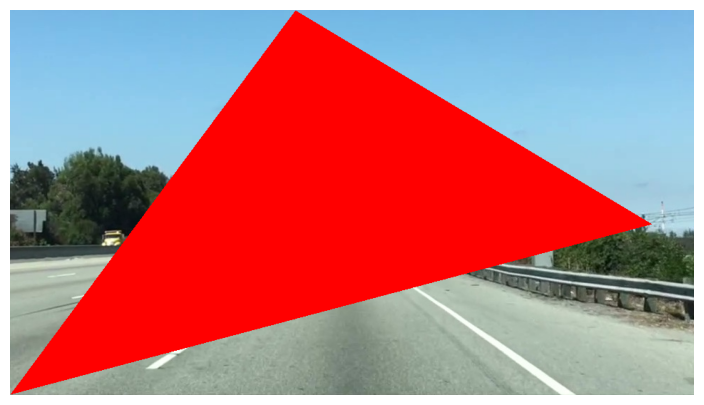

In [3]:
def triangle_mask(xsize, ysize, left_bottom, right_bottom, apex):
    fit_left   = np.polyfit((left_bottom[0],  apex[0]),         (left_bottom[1],  apex[1]),         1)
    fit_right  = np.polyfit((right_bottom[0], apex[0]),         (right_bottom[1], apex[1]),         1)
    fit_bottom = np.polyfit((left_bottom[0],  right_bottom[0]), (left_bottom[1],  right_bottom[1]), 1)
    XX, YY = np.meshgrid(np.arange(0, xsize), np.arange(0, ysize))
    return (YY > (XX * fit_left[0]  + fit_left[1])) & \
           (YY > (XX * fit_right[0] + fit_right[1])) & \
           (YY < (XX * fit_bottom[0] + fit_bottom[1]))

# Deliberately bad vertices (from the lesson) - see how the region looks:
left_bottom, right_bottom, apex = [0, 539], [900, 300], [400, 0]
region = triangle_mask(xsize, ysize, left_bottom, right_bottom, apex)

region_select = np.copy(image)
region_select[region] = [255, 0, 0]          # paint the inside of the region red
plt.figure(figsize=(9, 5)); plt.imshow(region_select); plt.axis("off"); plt.show()

MD## 2. Combine colour **and** region

A pixel is a lane-line pixel if it passes the colour test **and** lies inside the region: `~color_thresholds & region`.

In [4]:
def color_and_region(image, rgb_threshold, left_bottom, right_bottom, apex):
    color_thresholds = (image[:, :, 0] < rgb_threshold[0]) | \
                       (image[:, :, 1] < rgb_threshold[1]) | \
                       (image[:, :, 2] < rgb_threshold[2])
    region = triangle_mask(image.shape[1], image.shape[0], left_bottom, right_bottom, apex)
    color_select = np.copy(image); line_image = np.copy(image)
    color_select[color_thresholds | ~region] = [0, 0, 0]      # keep only colour AND region
    line_image[~color_thresholds & region] = [255, 0, 0]      # paint lane pixels red on the original
    return color_select, line_image

MD## 3. Quiz — find the triangle

The colour thresholds are given (200). Move `left_bottom`, `right_bottom` and `apex` until only the lane lines are painted red.

<details><summary><b>Show the answer</b> (try first!)</summary>

`left_bottom = [0, 539]`, `right_bottom = [900, 539]`, `apex = [475, 320]` (any triangle that hugs the lane works).
</details>

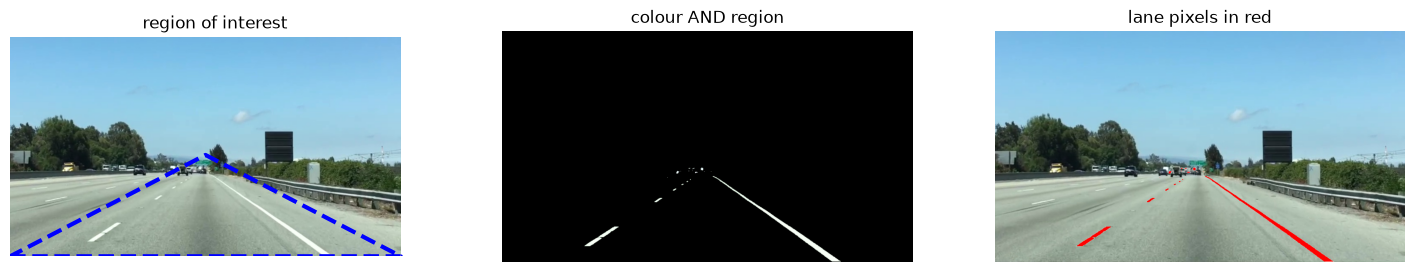

In [5]:
rgb_threshold = [200, 200, 200]

# MODIFY THESE VALUES TO ISOLATE THE REGION WHERE THE LANE LINES ARE
left_bottom  = [0, 539]
right_bottom = [960, 539]
apex         = [480, 290]

color_select, line_image = color_and_region(image, rgb_threshold, left_bottom, right_bottom, apex)
x = [left_bottom[0], right_bottom[0], apex[0], left_bottom[0]]
y = [left_bottom[1], right_bottom[1], apex[1], left_bottom[1]]

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].imshow(image); ax[0].plot(x, y, "b--", lw=3); ax[0].set_title("region of interest")
ax[1].imshow(color_select); ax[1].set_title("colour AND region")
ax[2].imshow(line_image); ax[2].set_title("lane pixels in red")
for a in ax: a.axis("off")
plt.show()

MD## 4. The practical way: any polygon with `cv2.fillPoly`

Real pipelines use a **trapezoid** (or any polygon) and OpenCV: draw the filled polygon on a black mask and `bitwise_and` it with
the image. This is what you will use in the project.

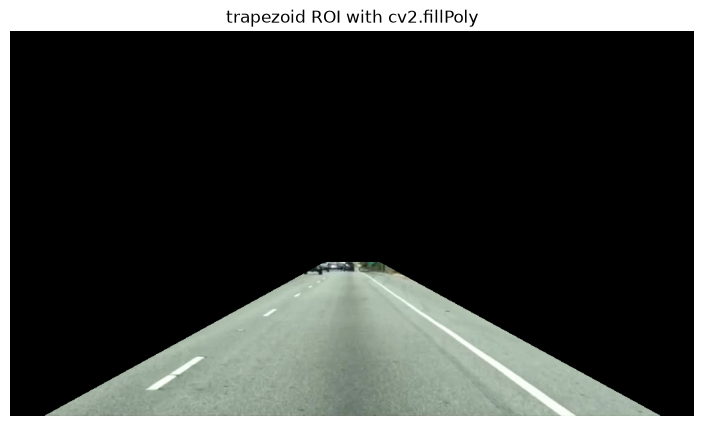

In [6]:
def region_of_interest(img, vertices):
    mask = np.zeros_like(img)
    fill = (255,) * img.shape[2] if img.ndim == 3 else 255
    cv2.fillPoly(mask, vertices, fill)
    return cv2.bitwise_and(img, mask)

h, w = image.shape[:2]
vertices = np.array([[(int(0.05 * w), h), (int(0.46 * w), int(0.6 * h)),
                      (int(0.54 * w), int(0.6 * h)), (int(0.95 * w), h)]], dtype=np.int32)
masked = region_of_interest(image, vertices)
plt.figure(figsize=(9, 5)); plt.imshow(masked); plt.title("trapezoid ROI with cv2.fillPoly"); plt.axis("off"); plt.show()

MD## Takeaway

Colour + region already isolates the lane lines on a clean, sunny, straight highway. But it still relies on the paint
colour and a fixed camera — next we use **shape**: edges (Lab 5C) and straight lines (Lab 5D).

## Your turn — Lab 5B tasks

1. Express your ROI vertices as **fractions** of the image width/height (like the trapezoid above) instead of pixels.
   Why does this matter when the video resolution changes (e.g. 960×540 vs 1280×720)?
2. Replace the triangle in Section 3 with the `cv2.fillPoly` trapezoid and show colour **and** region on `test.jpg`.
3. In two or three sentences: when would a fixed region of interest **fail** on a real car? (Think hills, lane changes, camera mounting.)

**Deliverable:** keep this notebook with your code, outputs and a short written answer to each task.